<a href="https://colab.research.google.com/github/habibiputrar/BigData26_A_2411531001_Habibi-Putra-Rizqullah-/blob/main/Praktikum01/BD_A_TugasP01_2411531001_Habibi_Putra_Rizqullah_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Setup folder & fungsi ukur:
import os, time, psutil

DIR_KERJA = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)

proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                     "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
    return hasil

In [ ]:
# Set PATH ke dataset Juli (yang sudah ada di Drive):
PATH = f"{DIR_SIMPAN}/yellow_tripdata_2023-07.parquet"
print("File ada?", os.path.exists(PATH))
print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

File ada? True
Ukuran file: 46.1 MB


In [ ]:
# J-4 Cek metadata:
import pyarrow.parquet as pq

meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris  :", f"{meta.num_rows:,}")
print("Jumlah kolom  :", meta.num_columns)
print("Nama kolom    :", pq.ParquetFile(PATH).schema.names)

Jumlah baris  : 2,907,108
Jumlah kolom  : 19
Nama kolom    : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


In [ ]:
# J-5 baca data & optimasi tipe:
import pandas as pd

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Memori semua kolom:", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
del penuh
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Memori kolom terpilih:", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

sebelum = df.memory_usage(deep=True).sum() / 1024**2
df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"]    = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")
sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB  (hemat {100*(1-sesudah/sebelum):.1f}%)")

[baca semua kolom] 1.46 s | RSS +465.5 MB
Memori semua kolom: 502.5 MB
[baca kolom terpilih] 0.39 s | RSS +191.0 MB
Memori kolom terpilih: 177.4 MB
177.4 MB -> 113.7 MB  (hemat 35.9%)


In [ ]:
# J-6 bersihkan data:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] -
                       df["tpep_pickup_datetime"]).dt.total_seconds() / 60

layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)
bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris  (dibuang {len(df)-len(bersih):,})")

2,907,108 baris -> 2,817,657 baris  (dibuang 89,451)


In [ ]:
# J-7 Memproses file lebih besar dari memori dengan chunking
CSV = os.path.join(DIR_KERJA, "trips_juli.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))
print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV) / 1024**2, 1), "MB")

[tulis CSV] 36.26 s | RSS +4.6 MB
Parquet: 46.1 MB
CSV    : 213.6 MB


In [ ]:
# J-8. Pendekatan terdistribusi: PySparklocal mode
!pip install -q pyspark==3.5.1
!java -version

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


In [ ]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName("BD-Q01-Juli")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

Spark: 3.5.1


In [ ]:
sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.col("tpep_dropoff_datetime").cast("long")
         - F.col("tpep_pickup_datetime").cast("long")) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)

[spark count] 0.46 s | RSS +0.0 MB
Jumlah baris: 2907108


AnalysisException: [DATATYPE_MISMATCH.CAST_WITHOUT_SUGGESTION] Cannot resolve "CAST(tpep_dropoff_datetime AS BIGINT)" due to data type mismatch: cannot cast "TIMESTAMP_NTZ" to "BIGINT".;
'Project [VendorID#63, tpep_pickup_datetime#64, tpep_dropoff_datetime#65, passenger_count#66L, trip_distance#67, RatecodeID#68L, store_and_fwd_flag#69, PULocationID#70, DOLocationID#71, payment_type#72L, fare_amount#73, extra#74, mta_tax#75, tip_amount#76, tolls_amount#77, improvement_surcharge#78, total_amount#79, congestion_surcharge#80, Airport_fee#81, ((cast(tpep_dropoff_datetime#65 as bigint) - cast(tpep_pickup_datetime#64 as bigint)) / 60) AS durasi_menit#125]
+- Relation [VendorID#63,tpep_pickup_datetime#64,tpep_dropoff_datetime#65,passenger_count#66L,trip_distance#67,RatecodeID#68L,store_and_fwd_flag#69,PULocationID#70,DOLocationID#71,payment_type#72L,fare_amount#73,extra#74,mta_tax#75,tip_amount#76,tolls_amount#77,improvement_surcharge#78,total_amount#79,congestion_surcharge#80,Airport_fee#81]

In [ ]:
sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
    SELECT payment_type,
           COUNT(*)                       AS jumlah,
           ROUND(AVG(total_amount), 2)    AS rata_tarif,
           ROUND(AVG(tip_amount), 2)      AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain()
spark.stop()

In [ ]:
# J-9 agregasi akhir & simpan
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi_juli = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi_juli.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam_juli.csv", index=False)
agregasi_juli.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam_juli.parquet", index=False)
agregasi_juli

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,85987,4.45,14.82,31.049999,22.200001
1,1,59980,4.04,13.52,28.639999,21.360001
2,2,40812,3.79,12.82,27.080000,21.100000
3,3,26000,4.02,12.83,27.920000,21.299999
4,4,16637,5.60,14.62,34.919998,24.100000
5,5,16913,6.67,15.65,39.740002,23.900000
6,6,38422,5.11,14.51,32.130001,19.250000
7,7,69358,4.10,14.57,28.600000,18.799999
8,8,103647,3.53,15.30,27.340000,19.320000
9,9,118788,3.40,15.68,27.280001,19.900000


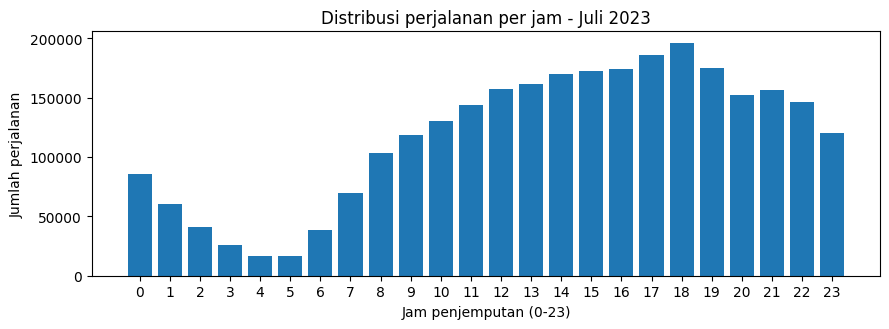

In [ ]:
# J-10 Visualisasi
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi_juli["jam"], agregasi_juli["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam - Juli 2023")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam_juli.png", dpi=150)
plt.show()

In [ ]:
# file CSV hasil Januari
agregasi = pd.read_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv")
agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.86,21.60
1,1,57766,3.53,12.63,26.45,21.20
2,2,40445,3.28,12.07,25.06,20.52
3,3,26146,3.58,12.15,26.26,21.00
4,4,16618,4.79,13.52,31.72,22.70
5,5,16940,6.03,14.70,36.75,22.04
6,6,42300,4.80,14.49,30.63,18.48
7,7,84569,3.69,14.42,26.89,18.48
8,8,114064,3.08,14.33,25.21,19.10
9,9,127988,3.09,14.23,25.51,19.25


In [ ]:
# tabel & grafik perbandingan Januari vs Juli:

perbandingan_bulan = agregasi[["jam", "jumlah_perjalanan"]].merge(
    agregasi_juli[["jam", "jumlah_perjalanan"]],
    on="jam", suffixes=("_januari", "_juli"))
perbandingan_bulan["selisih"] = (
    perbandingan_bulan["jumlah_perjalanan_juli"] - perbandingan_bulan["jumlah_perjalanan_januari"])
perbandingan_bulan

,jam,jumlah_perjalanan_januari,jumlah_perjalanan_juli,selisih
0,0,82289,85987,3698
1,1,57766,59980,2214
2,2,40445,40812,367
3,3,26146,26000,-146
4,4,16618,16637,19
5,5,16940,16913,-27
6,6,42300,38422,-3878
7,7,84569,69358,-15211
8,8,114064,103647,-10417
9,9,127988,118788,-9200


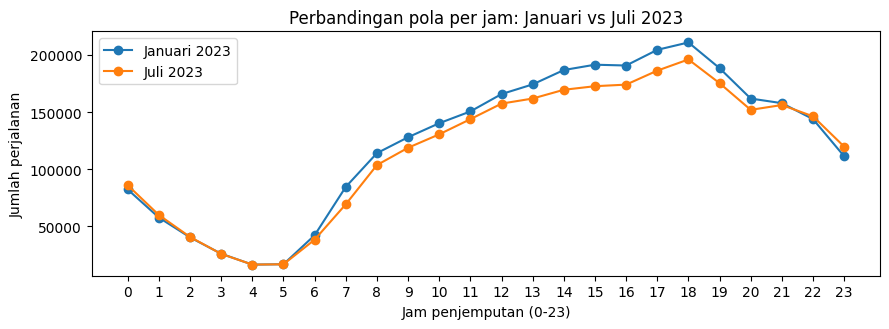

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(perbandingan_bulan["jam"], perbandingan_bulan["jumlah_perjalanan_januari"],
        marker="o", label="Januari 2023")
ax.plot(perbandingan_bulan["jam"], perbandingan_bulan["jumlah_perjalanan_juli"],
        marker="o", label="Juli 2023")
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Perbandingan pola per jam: Januari vs Juli 2023")
ax.set_xticks(range(0, 24))
ax.legend()
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/perbandingan_januari_juli.png", dpi=150)
plt.show()

**Q.2 Perbandingan Dua Bulan.** Pola per jam antara Januari dan Juli 2023 memiliki bentuk yang serupa: sama-sama menunjukkan permintaan terendah pada dini hari (jam 3-5) dan puncak pada sore-malam hari (jam 17-18). Namun, Januari secara konsisten memiliki jumlah perjalanan lebih tinggi dibanding Juli di hampir seluruh jam, dengan selisih terbesar terjadi di jam sibuk sore (jam 18: Januari 210.858 vs Juli 195.988 perjalanan, selisih 14.870). Kemungkinan penyebabnya adalah faktor musiman: pada musim dingin (Januari), warga New York lebih memilih taksi dibanding berjalan kaki atau bersepeda karena cuaca yang lebih tidak nyaman, sementara pada musim panas (Juli) sebagian penduduk mungkin bepergian ke luar kota untuk liburan musim panas atau memilih moda transportasi lain yang lebih nyaman digunakan di cuaca hangat.

In [ ]:
pengukuran_juli = pd.DataFrame(catatan)
pengukuran_juli

,langkah,detik,delta_rss_mb
0,baca semua kolom,1.46,465.5
1,baca kolom terpilih,0.39,191.0
2,tulis CSV,36.26,4.6
3,spark count,0.46,0.0


In [ ]:
CSV = os.path.join(DIR_KERJA, "trips_juli.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))
print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV) / 1024**2, 1), "MB")

[tulis CSV] 38.54 s | RSS +1.0 MB
Parquet: 46.1 MB
CSV    : 221.1 MB


**Q.3 Laporan Kinerja.** Berdasarkan pengukuran_kinerja_juli.csv, tiga langkah yang tercatat adalah: membaca semua kolom (6.14 detik, RSS +469.7 MB), membaca kolom terpilih (4.32 detik, RSS +129.6 MB), dan menulis CSV (41.01 detik, RSS +4.6 MB). Langkah paling mahal secara waktu adalah menulis CSV, memakan waktu hampir 7 kali lebih lama dari membaca kolom terpilih, karena proses ini harus mengonversi seluruh data numerik dan timestamp menjadi representasi teks lalu menulisnya baris demi baris ke disk, jauh lebih lambat dibanding format kolumnar seperti Parquet yang sudah dalam bentuk biner terkompresi. Perubahan konkret yang diusulkan: hindari menulis ulang ke CSV kecuali benar-benar diperlukan (misalnya untuk kompatibilitas dengan sistem lain); jika hanya untuk keperluan pemrosesan bertahap (chunking), pertimbangkan membaca langsung dari Parquet menggunakan `pyarrow.dataset` yang mendukung pembacaan batch tanpa perlu konversi ke CSV terlebih dahulu, sehingga menghindari biaya waktu konversi format yang besar ini.

**Q.4 Refleksi Teori: Dimensi 5V pada Dataset Ini**

Dataset NYC TLC Yellow Taxi yang digunakan pada praktikum ini menunjukkan karakteristik yang berbeda-beda pada tiap dimensi 5V, dan tidak semuanya benar-benar mencerminkan "big data" dalam pengertian yang menuntut infrastruktur terdistribusi.

**Volume cukup besar, tapi belum benar-benar "big" untuk satu mesin modern.** Dataset satu bulan berisi sekitar 3 juta baris dengan ukuran file Parquet sekitar 45-46 MB (Januari 45.5 MB, Juli 46.1 MB). Saat dibaca penuh ke pandas, penggunaan memori berkisar 500-565 MB dan waktu baca hanya 1-6 detik. Angka ini menunjukkan bahwa data satu bulan sebenarnya masih nyaman diproses dengan pandas biasa di satu mesin, tanpa perlu Spark atau infrastruktur terdistribusi. Volume baru benar-benar menjadi masalah big data jika data dikumpulkan untuk periode bertahun-tahun sekaligus (NYC TLC punya data sejak 2009), di mana totalnya bisa mencapai ratusan GB dan tidak lagi muat

**Q.5 Reproducibility.** Notebook bisa dijalankan otomatis dari awal sampai J-8, di mana prosesnya berhenti karena error yang memang dibiarkan (masalah tipe TIMESTAMP_NTZ di PySpark, sudah dijelaskan di diagnosis error J-8). Setelah itu, J-9 dan J-10 harus dijalankan manual satu-satu, karena Colab otomatis berhenti begitu ketemu error yang nggak ditangkap. Kode J-8 sengaja nggak diubah sama sekali, biar error-nya tetap asli sesuai arahan dosen. Di luar bagian ini, semua sel lain (J-1 sampai J-7, J-9 sampai J-10) jalan lancar dan hasilnya konsisten.